                                 DETAILED POINT-BY-POINT ORDINARY LEAST SQUARES CALCULATIONS

👉 [ DATASET STEP: First 2 Points ]
   Dataset Iter.   | Latest X | Latest Logit | Mean X   | Mean Logit | Dev. X   | Dev. Logit | Prod. Dev.   | Sum Prod (Num)  | Sq. Dev (Den)  | Weight (m) | Bias (b)     
   -------------------------------------------------------------------------------------------------------------------------------------------------------------
                   | 2.0      | -2.44        | 3.00     | -2.44      | -1.00    | 0.00       | -0.00        | -               | -              | -          | -            
   First 2 Pts     | 4.0      | -2.44        | 3.00     | -2.44      | 1.00     | 0.00       | 0.00         | -               | -              | -          | -            
   📊 Final Row     | 4.0      | -2.44        | 3.00     | -2.44      | 1.00     | 0.00       | 0.00         | 0.00            | 2.00           | 0.000      | -2.442       
   -------------------

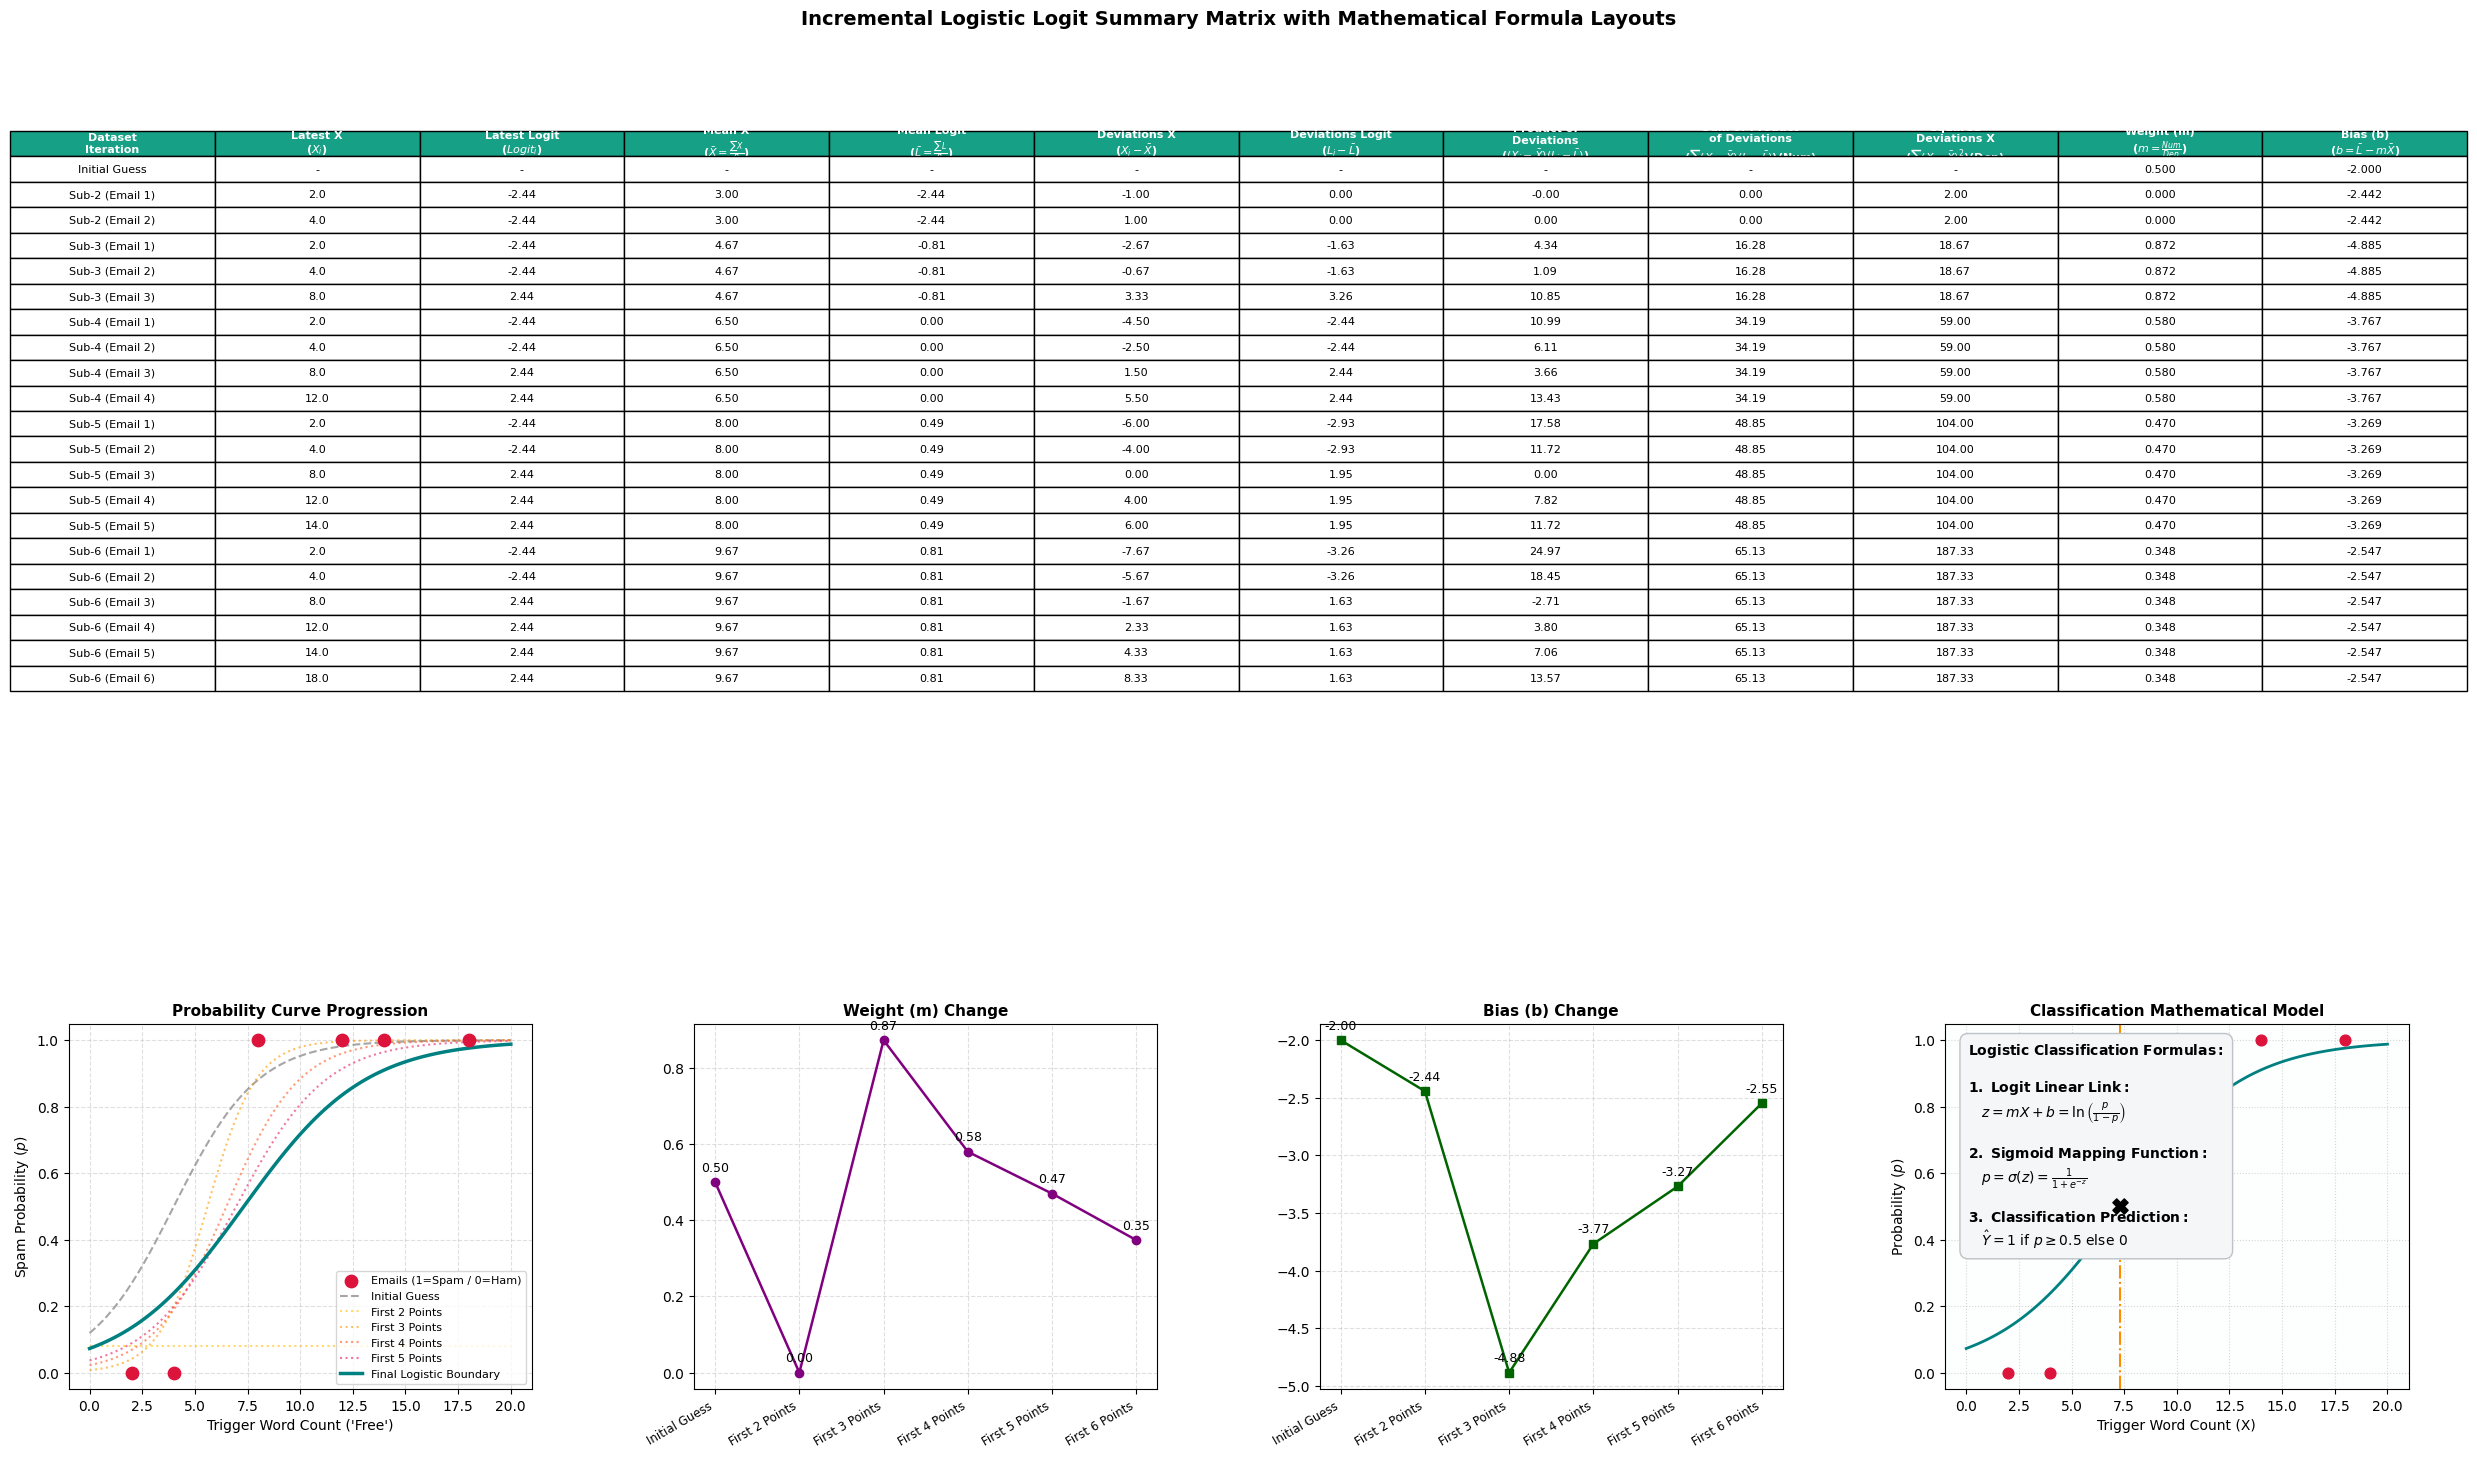

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Dataset (1 = Spam, 0 = Ham/Regular Email)
X = np.array([2, 4, 8, 12, 14, 18], dtype=float)  # Trigger word count
Y_raw = np.array([0, 0, 1, 1, 1, 1], dtype=float)  # Classification label

# Smooth binary inputs for continuous analytical logit mapping: log(p / (1-p))
# Avoids division by zero or log(0) issues during strict analytical tracking matrix compilation
Y = np.where(Y_raw == 1, 0.92, 0.08)
Logits = np.log(Y / (1.0 - Y))


class CustomDetailedClassifier:

  def __init__(self, initial_weight=0.5, initial_bias=-2.0):
    self.history_m = [initial_weight]
    self.history_b = [initial_bias]
    self.labels = ["Initial Guess"]

    domain = np.linspace(0, 20, 100)
    self.history_curves = [1.0 / (1.0 + np.exp(-(initial_weight * domain + initial_bias)))]

    # Structure to hold summary rows for our 12-column Matplotlib visual table
    self.summary_table_data = [[
        "Initial Guess", "-", "-", "-", "-", "-", "-", "-", "-", "-",
        f"{initial_weight:.3f}", f"{initial_bias:.3f}"
    ]]

  def fit_and_print_details(self, x_data, logit_data):
    print("=" * 155)
    print("                                 DETAILED POINT-BY-POINT ORDINARY LEAST SQUARES CALCULATIONS")
    print("=" * 155)

    # Process subsets incrementally from the first 2 points up to all 6 points
    for i in range(2, len(x_data) + 1):
      x_sub = x_data[:i]
      logit_sub = logit_data[:i]

      x_mean = np.mean(x_sub)
      logit_mean = np.mean(logit_sub)

      print(f"\n👉 [ DATASET STEP: First {i} Points ]")
      print(
          f"   {'Dataset Iter.':<15} | {'Latest X':<8} | {'Latest Logit':<12} |"
          f" {'Mean X':<8} | {'Mean Logit':<10} | {'Dev. X':<8} | {'Dev. Logit':<10} |"
          f" {'Prod. Dev.':<12} | {'Sum Prod (Num)':<15} | {'Sq. Dev (Den)':<14}"
          f" | {'Weight (m)':<10} | {'Bias (b)':<13}"
      )
      print(f"   {'-'*157}")

      total_numerator = 0.0
      total_denominator = 0.0
      sub_iteration_rows = []

      for idx in range(len(x_sub)):
        x_val = x_sub[idx]
        l_val = logit_sub[idx]

        dx = x_val - x_mean
        dl = l_val - logit_mean
        num_item = dx * dl
        den_item = dx**2

        total_numerator += num_item
        total_denominator += den_item

        iter_label = f"First {i} Pts" if idx == len(x_sub) - 1 else ""
        print(
            f"   {iter_label:<15} | {x_val:<8.1f} | {l_val:<12.2f} |"
            f" {x_mean:<8.2f} | {logit_mean:<10.2f} | {dx:<8.2f} | {dl:<10.2f} |"
            f" {num_item:<12.2f} | {'-':<15} | {'-':<14} | {'-':<10} | {'-':<13}"
        )

        # Store the individual point metrics dynamically
        sub_iteration_rows.append([
            f"Sub-{i} (Email {idx+1})",
            f"{x_val:.1f}",
            f"{l_val:.2f}",
            f"{x_mean:.2f}",
            f"{logit_mean:.2f}",
            f"{dx:.2f}",
            f"{dl:.2f}",
            f"{num_item:.2f}"
        ])

      m = total_numerator / total_denominator if total_denominator != 0 else 0
      b = logit_mean - m * x_mean

      print(
          f"   {'📊 Final Row':<15} | {x_val:<8.1f} | {l_val:<12.2f} |"
          f" {x_mean:<8.2f} | {logit_mean:<10.2f} | {dx:<8.2f} | {dl:<10.2f} |"
          f" {num_item:<12.2f} | {total_numerator:<15.2f} |"
          f" {total_denominator:<14.2f} | {m:<10.3f} | {b:<13.3f}"
      )
      print(f"   {'-'*157}")

      self.history_m.append(m)
      self.history_b.append(b)
      self.labels.append(f"First {i} Points")

      domain = np.linspace(0, 20, 100)
      self.history_curves.append(1.0 / (1.0 + np.exp(-(m * domain + b))))

      # Append rows with finalized calculations to our table matrix template
      for row in sub_iteration_rows:
        row.append(f"{total_numerator:.2f}")
        row.append(f"{total_denominator:.2f}")
        row.extend([f"{m:.3f}", f"{b:.3f}"])
        self.summary_table_data.append(row)


# 2. Run Cumulative Detailed Fit Execution
model = CustomDetailedClassifier(initial_weight=0.5, initial_bias=-2.0)
model.fit_and_print_details(X, Logits)

# 3. Plotting Setup (Grid Layout: Table Top, Subplots Below)
fig = plt.figure(figsize=(26, 16))
grid = fig.add_gridspec(2, 4, height_ratios=[2.0, 1.0], hspace=0.45, wspace=0.35)

# --- TOP ROW: CORRECTED 12-COLUMN DATA BOARD MATRIX ---
ax_table = fig.add_subplot(grid[0, :])
ax_table.axis("off")

headers = [
    "Dataset\nIteration",
    "Latest X\n($X_i$)",
    "Latest Logit\n($Logit_i$)",
    "Mean X\n($\\bar{X} = \\frac{\\sum X}{n}$)",
    "Mean Logit\n($\\bar{L} = \\frac{\\sum L}{n}$)",
    "Deviations X\n($X_i - \\bar{X}$)",
    "Deviations Logit\n($L_i - \\bar{L}$)",
    "Product of\nDeviations\n($(X_i - \\bar{X})(L_i - \\bar{L})$)",
    "Sum of Product\nof Deviations\n($\\sum (X - \\bar{X})(L - \\bar{L})$)(Num)",
    "Squared\nDeviations X\n($\\sum (X - \\bar{X})^2$)(Den)",
    "Weight (m)\n($m = \\frac{Num}{Den}$)",
    "Bias (b)\n($b = \\bar{L} - m\\bar{X}$)",
]

table = ax_table.table(
    cellText=model.summary_table_data,
    colLabels=headers,
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.05, 1.4)

for col_idx in range(len(headers)):
  cell = table[0, col_idx]
  cell.set_facecolor("#16A085")
  cell.get_text().set_color("white")
  cell.get_text().set_weight("bold")

ax_table.set_title(
    "Incremental Logistic Logit Summary Matrix with Mathematical Formula Layouts",
    fontsize=14,
    weight="bold",
    pad=15,
)

# --- BOTTOM ROW: COMPARISON DIAGNOSTIC PLOTS ---
domain_x = np.linspace(0, 20, 100)

# Plot 1: Sigmoid Probability Curve Progression
ax1 = fig.add_subplot(grid[1, 0])
ax1.scatter(X, Y_raw, color="crimson", label="Emails (1=Spam / 0=Ham)", s=80, zorder=5)
ax1.plot(domain_x, model.history_curves[0], color="gray", linestyle="--", alpha=0.7, label="Initial Guess")

colors = ["#FFC107", "#FF9800", "#FF5722", "#E91E63"]
for idx, curve in enumerate(model.history_curves[1:-1], start=1):
  ax1.plot(domain_x, curve, color=colors[idx - 1], linestyle=":", alpha=0.6, label=f"{model.labels[idx]}")

ax1.plot(domain_x, model.history_curves[-1], color="teal", linewidth=2.5, label="Final Logistic Boundary")
ax1.set_title("Probability Curve Progression", fontsize=11, weight="bold")
ax1.set_xlabel("Trigger Word Count ('Free')")
ax1.set_ylabel("Spam Probability ($p$)")
ax1.legend(fontsize=8, loc="lower right")
ax1.grid(True, linestyle="--", alpha=0.4)

# Plot 2: Weight Parameter History Tracking
ax2 = fig.add_subplot(grid[1, 1])
ax2.plot(model.labels, model.history_m, marker="o", color="purple", linewidth=1.8, label="Weight (m)")
for i, val in enumerate(model.history_m):
  ax2.annotate(f"{val:.2f}", (model.labels[i], model.history_m[i]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax2.set_title("Weight (m) Change", fontsize=11, weight="bold")
ax2.set_xticks(range(len(model.labels)))
ax2.set_xticklabels(model.labels, rotation=30, ha="right", fontsize=8.5)
ax2.grid(True, linestyle="--", alpha=0.4)

# Plot 3: Bias Parameter History Tracking
ax3 = fig.add_subplot(grid[1, 2])
ax3.plot(model.labels, model.history_b, marker="s", color="darkgreen", linewidth=1.8, label="Bias (b)")
for i, val in enumerate(model.history_b):
  ax3.annotate(f"{val:.2f}", (model.labels[i], model.history_b[i]), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)
ax3.set_title("Bias (b) Change", fontsize=11, weight="bold")
ax3.set_xticks(range(len(model.labels)))
ax3.set_xticklabels(model.labels, rotation=30, ha="right", fontsize=8.5)
ax3.grid(True, linestyle="--", alpha=0.4)

# Plot 4: Complete Logistic Regression Formula Graph Matrix
ax4 = fig.add_subplot(grid[1, 3])
ax4.set_facecolor("#FDFEFE")

final_m, final_b = model.history_m[-1], model.history_b[-1]
# Fixed: Handled raw string string literal escaping warning layout cleanly
ax4.plot(domain_x, 1.0 / (1.0 + np.exp(-(final_m * domain_x + final_b))), color="teal", linewidth=2, label=r"$\sigma(z)$", zorder=2)
ax4.scatter(X, Y_raw, color="crimson", s=60, zorder=3)

# Calculate decision boundary point: Where z = 0 -> p = 0.5
boundary_x = -final_b / final_m
ax4.axvline(boundary_x, color="darkorange", linestyle="-.", linewidth=1.5, label=f"Decision Cutoff ({boundary_x:.2f})")
ax4.scatter([boundary_x], [0.5], color="black", s=120, marker="X", zorder=4)

formula_text = (
    r"$\mathbf{Logistic\ Classification\ Formulas:}$" "\n\n"
    r"$\mathbf{1.\ Logit\ Linear\ Link:}$" "\n"
    r"   $z = mX + b = \ln\left(\frac{p}{1-p}\right)$" "\n\n"
    r"$\mathbf{2.\ Sigmoid\ Mapping\ Function:}$" "\n"
    r"   $p = \sigma(z) = \frac{1}{1 + e^{-z}}$" "\n\n"
    r"$\mathbf{3.\ Classification\ Prediction:}$" "\n"
    r"   $\hat{Y} = 1 \text{ if } p \geq 0.5 \text{ else } 0$"
)

ax4.text(0.05, 0.95, formula_text, transform=ax4.transAxes, fontsize=10, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.6", facecolor="#F4F6F7", edgecolor="#BDC3C7"))

ax4.set_title("Classification Mathematical Model", fontsize=11, weight="bold")
ax4.set_xlabel("Trigger Word Count (X)")
ax4.set_ylabel("Probability ($p$)")
ax4.grid(True, linestyle=":", alpha=0.5)

# Fixed: Replaced conflicting tight_layout with explicit manual bounding layout coordinates
plt.subplots_adjust(top=0.92, bottom=0.08, left=0.05, right=0.95, hspace=0.4, wspace=0.3)
plt.show()
